# Dependancies 

In [1]:

import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

# --- 1. Load and Prepare Your Data ---

In [2]:

# Replace this with your actual data loading mechanism.
# For demonstration, I'm creating a sample DataFrame.
# Imagine you have a CSV file named 'eis_data.csv' with columns:
# Frequency, Rs, Cp, X, PH

# Sample Data Creation (REPLACE THIS WITH YOUR DATA LOADING)
data = {
    'Frequency(Hz)': [0.1, 1, 10, 100, 1000, 10000, 100000],
    'Rs': [10.5, 10.2, 9.8, 8.5, 5.0, 2.0, 1.0],
    'Cp': [1e-5, 9e-6, 8e-6, 5e-6, 2e-6, 1e-7, 5e-8],
    'X': [-1591, -176.8, -19.89, -3.18, -0.79, -0.159, -0.031], # Calculated as -1/(2*pi*f*C) for series RC
    'PH': [-89.0, -85.0, -75.0, -60.0, -45.0, -20.0, -5.0]
}
# Add more data points for a more realistic PCA
data['Frequency(Hz)'].extend([0.5, 5, 50, 500, 5000, 50000])
data['Rs'].extend([10.3, 10.0, 9.0, 6.5, 3.0, 1.5])
data['Cp'].extend([9.5e-6, 8.5e-6, 6e-6, 3e-6, 5e-7, 8e-8])
data['X'].extend([-340, -40, -6, -1, -0.5, -0.08])
data['PH'].extend([-87.0, -80.0, -70.0, -55.0, -30.0, -10.0])

df = pd.DataFrame(data)

# If loading from CSV:
# df = pd.read_csv('your_eis_data.csv')

print("--- Original Data (First 5 rows) ---")
print(df.head())
print("\n")

# Separate features (X) from any target variable (y) if you have one.
# For PCA, we only need the features.
features = ['Frequency(Hz)', 'Rs', 'Cp', 'X', 'PH']
x_data = df[features].values

--- Original Data (First 5 rows) ---
   Frequency(Hz)    Rs        Cp        X    PH
0            0.1  10.5  0.000010 -1591.00 -89.0
1            1.0  10.2  0.000009  -176.80 -85.0
2           10.0   9.8  0.000008   -19.89 -75.0
3          100.0   8.5  0.000005    -3.18 -60.0
4         1000.0   5.0  0.000002    -0.79 -45.0




# --- 2. Feature Scaling ---

In [3]:
# Standardizing the features (mean=0, std=1)
scaler = StandardScaler()
x_scaled = scaler.fit_transform(x_data)

print("--- Scaled Data (First 5 rows) ---")
print(pd.DataFrame(x_scaled, columns=features).head())
print("\n")

--- Scaled Data (First 5 rows) ---
   Frequency(Hz)        Rs        Cp         X        PH
0      -0.451332  1.056193  1.378586 -3.373080 -1.188704
1      -0.451300  0.972470  1.116075 -0.021687 -1.050110
2      -0.450983  0.860840  0.853565  0.350160 -0.703627
3      -0.447815  0.498042  0.066032  0.389760 -0.183903
4      -0.416131 -0.478722 -0.721501  0.395424  0.335822




# --- 3. PCA Application ---

In [4]:
pca = PCA(n_components=5)
# Use the scaled data for PCA transformation
principal_components = pca.fit_transform(x_scaled)

# Dynamically create column names based on the actual number of components returned
pc_columns = [f'PC{i+1}' for i in range(principal_components.shape[1])]
principal_df = pd.DataFrame(data=principal_components, columns=pc_columns)

print("--- PCA Applied ---")
print(f"Original number of features: {x_scaled.shape[1]}")
if isinstance(pca.n_components_, float) and 0 < pca.n_components_ < 1:
    print(f"Variance threshold for components: {pca.n_components_}")
elif isinstance(pca.n_components_, int):
    print(f"Number of components requested: {pca.n_components_}")
else:
    print(f"Components determined by PCA: {pca.n_components_}")

print("\n--- Principal Components (First 5 rows) ---")
print(principal_df.head())


# Create a DataFrame for the principal components
pc_columns = [f'PC{i+1}' for i in range(pca.n_components_ if isinstance(pca.n_components_, int) else pca.n_features_in_)]
principal_df = pd.DataFrame(data=principal_components, columns=pc_columns)

print("\n--- Principal Components (First 5 rows) ---")
print(principal_df.head())
print("\n")

--- PCA Applied ---
Original number of features: 5
Number of components requested: 5

--- Principal Components (First 5 rows) ---
        PC1       PC2       PC3       PC4       PC5
0 -2.972471 -2.556663 -0.797270 -0.046488  0.022797
1 -1.769311  0.293510  0.516464  0.099391 -0.070519
2 -1.297169  0.593207  0.493151  0.070506  0.089419
3 -0.440871  0.617432  0.026705 -0.187036  0.165505
4  0.727809  0.533798 -0.603424 -0.076485 -0.086158

--- Principal Components (First 5 rows) ---
        PC1       PC2       PC3       PC4       PC5
0 -2.972471 -2.556663 -0.797270 -0.046488  0.022797
1 -1.769311  0.293510  0.516464  0.099391 -0.070519
2 -1.297169  0.593207  0.493151  0.070506  0.089419
3 -0.440871  0.617432  0.026705 -0.187036  0.165505
4  0.727809  0.533798 -0.603424 -0.076485 -0.086158




# --- 4. Analysis of Results ---

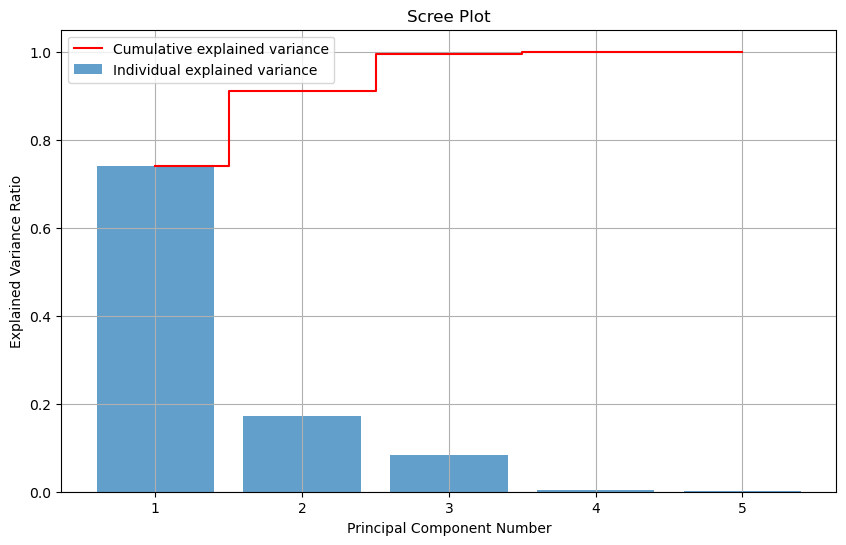

--- Explained Variance ---
Principal Component 1: Explained Variance Ratio = 0.7406 (Cumulative = 0.7406)
Principal Component 2: Explained Variance Ratio = 0.1712 (Cumulative = 0.9118)
Principal Component 3: Explained Variance Ratio = 0.0839 (Cumulative = 0.9957)
Principal Component 4: Explained Variance Ratio = 0.0031 (Cumulative = 0.9988)
Principal Component 5: Explained Variance Ratio = 0.0012 (Cumulative = 1.0000)


--- Component Loadings (Correlation of original features with PCs) ---
                    PC1       PC2       PC3       PC4       PC5
Frequency(Hz)  0.385120 -0.502264  0.747321 -0.166515 -0.114886
Rs            -0.506715  0.105411  0.277226 -0.611591  0.530312
Cp            -0.498441 -0.093094  0.389993  0.743323  0.195619
X              0.286023  0.849202  0.435697  0.078248 -0.033026
PH             0.514460 -0.082511 -0.150768  0.198942  0.816219




In [5]:
# Explained variance ratio: Percentage of variance explained by each of the selected components.
explained_variance_ratio = pca.explained_variance_ratio_
cumulative_explained_variance = np.cumsum(pca.explained_variance_ratio_)

# Scree Plot: Plot of explained variance for each principal component
plt.figure(figsize=(10, 6))
plt.bar(range(1, len(pca.explained_variance_ratio_) + 1),
        pca.explained_variance_ratio_,
        alpha=0.7,
        align='center',
        label='Individual explained variance')
plt.step(range(1, len(cumulative_explained_variance) + 1),
         cumulative_explained_variance,
         where='mid',
         label='Cumulative explained variance',
         color='red')
plt.ylabel('Explained Variance Ratio')
plt.xlabel('Principal Component Number')
plt.title('Scree Plot')
plt.xticks(range(1, len(pca.explained_variance_ratio_) + 1))
plt.legend(loc='best')
plt.grid(True)
plt.show()


print("--- Explained Variance ---")
for i, ratio in enumerate(explained_variance_ratio):
    print(f"Principal Component {i+1}: Explained Variance Ratio = {ratio:.4f} (Cumulative = {cumulative_explained_variance[i]:.4f})")
print("\n")

# Loadings: The correlation between the original variables and the principal components.
# This helps understand what original features each PC represents.
if hasattr(pca, 'components_'):
    loadings = pca.components_
    loadings_df = pd.DataFrame(loadings.T, columns=pc_columns, index=features)
    print("--- Component Loadings (Correlation of original features with PCs) ---")
    print(loadings_df)
    print("\n")

# --- 5. Visualization ---

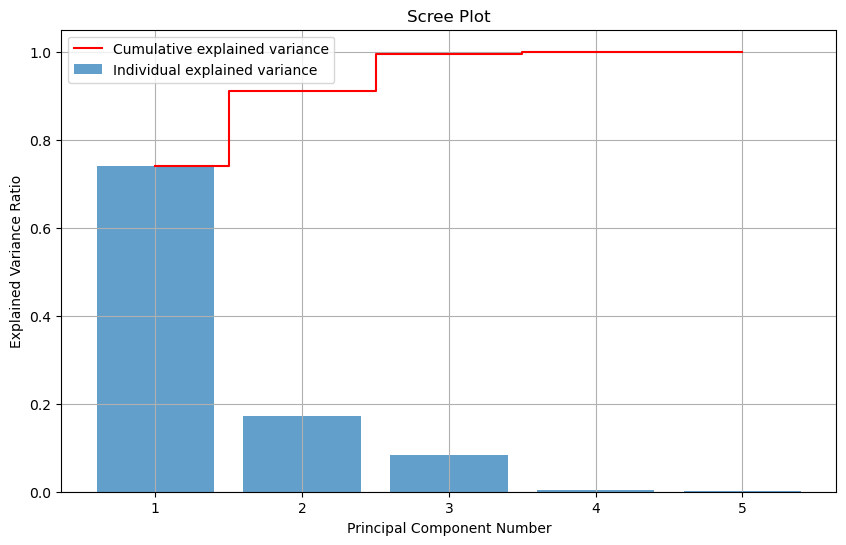

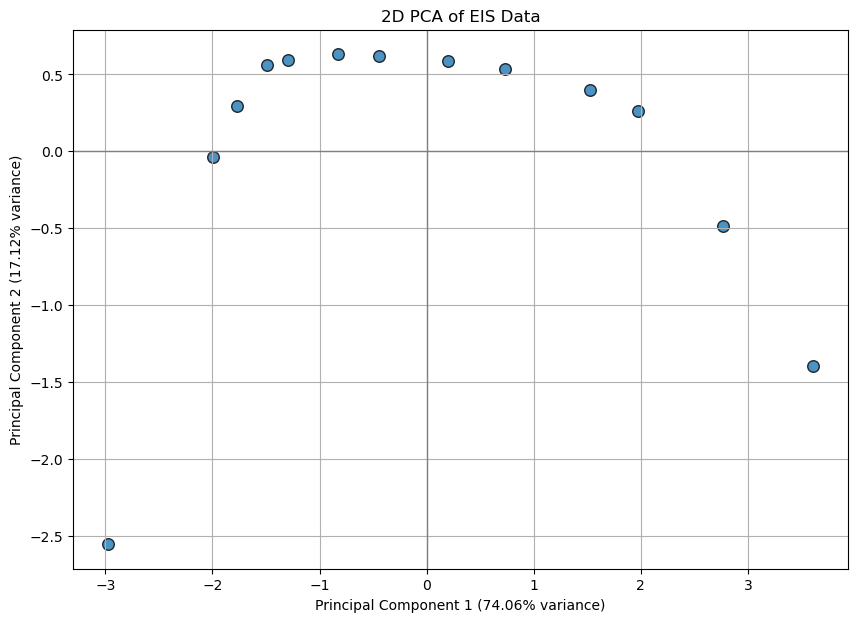

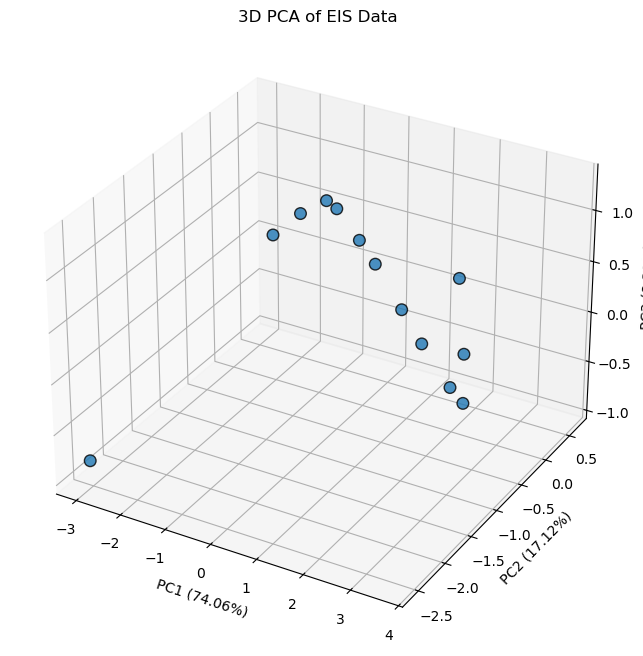

C:\Users\austi\AppData\Local\Temp\ipykernel_23072\3305910029.py:57: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  plt.arrow(0, 0, loadings_df['PC1'][i] * scale_factor, loadings_df['PC2'][i] * scale_factor,
C:\Users\austi\AppData\Local\Temp\ipykernel_23072\3305910029.py:59: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  plt.text(loadings_df['PC1'][i] * scale_factor * 1.15, loadings_df['PC2'][i] * scale_factor * 1.15,


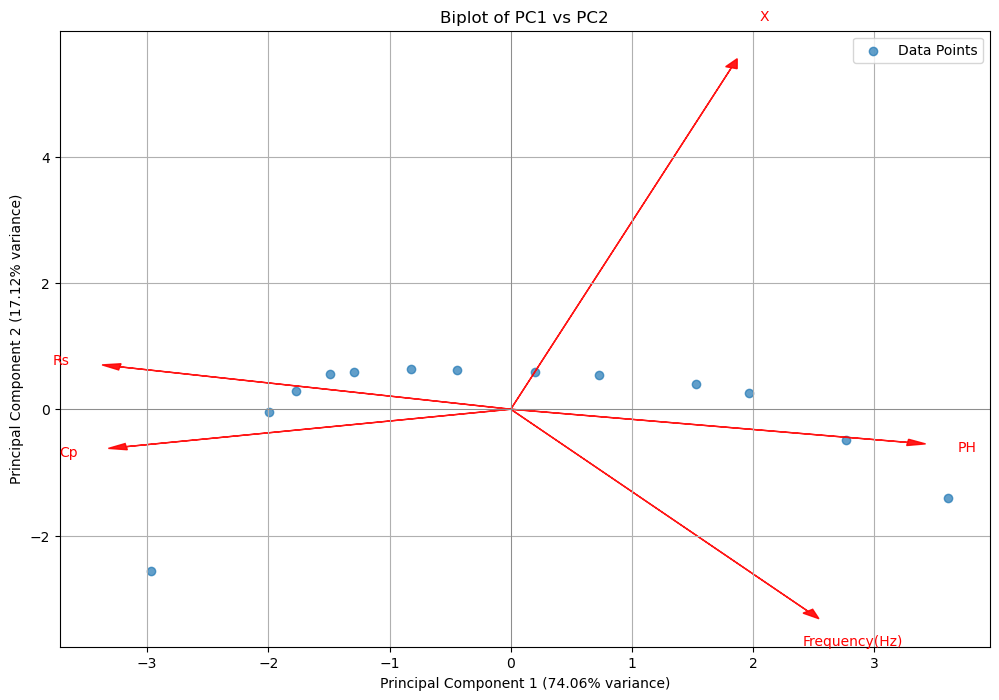

In [6]:
# Scree Plot: Plot of explained variance for each principal component
if hasattr(pca, 'explained_variance_ratio_'):
    plt.figure(figsize=(10, 6))
    plt.bar(range(1, len(pca.explained_variance_ratio_) + 1), pca.explained_variance_ratio_, alpha=0.7, align='center',
            label='Individual explained variance')
    cumulative_explained_variance = np.cumsum(pca.explained_variance_ratio_)
    plt.step(range(1, len(cumulative_explained_variance) + 1),
         cumulative_explained_variance,
         where='mid',
         label='Cumulative explained variance',
         color='red')
    plt.ylabel('Explained Variance Ratio')
    plt.xlabel('Principal Component Number')
    plt.title('Scree Plot')
    plt.xticks(range(1, len(pca.explained_variance_ratio_) + 1))
    plt.legend(loc='best')
    plt.grid(True)
    plt.show()

# Scatter Plot of the first two Principal Components
if principal_df.shape[1] >= 2:
    plt.figure(figsize=(10, 7))
    # You can color points by a known category if you have one.
    # For example, if your df had a 'Material_Type' column:
    # categories = df['Material_Type'].astype('category').cat.codes
    # plt.scatter(principal_df['PC1'], principal_df['PC2'], c=categories, cmap='viridis', edgecolor='k', s=70)
    # plt.colorbar(label='Material Type (Encoded)')
    plt.scatter(principal_df['PC1'], principal_df['PC2'], edgecolor='k', s=70, alpha=0.8)
    plt.xlabel('Principal Component 1 ({:.2f}% variance)'.format(pca.explained_variance_ratio_[0]*100))
    plt.ylabel('Principal Component 2 ({:.2f}% variance)'.format(pca.explained_variance_ratio_[1]*100))
    plt.title('2D PCA of EIS Data')
    plt.grid(True)
    plt.axhline(0, color='grey', lw=1)
    plt.axvline(0, color='grey', lw=1)
    plt.show()

    # 3D Scatter Plot if you have at least 3 components and want to visualize
    if principal_df.shape[1] >= 3:
        fig = plt.figure(figsize=(10, 8))
        ax = fig.add_subplot(111, projection='3d')
        ax.scatter(principal_df['PC1'], principal_df['PC2'], principal_df['PC3'], edgecolor='k', s=70, alpha=0.8)
        ax.set_xlabel('PC1 ({:.2f}%)'.format(pca.explained_variance_ratio_[0]*100))
        ax.set_ylabel('PC2 ({:.2f}%)'.format(pca.explained_variance_ratio_[1]*100))
        ax.set_zlabel('PC3 ({:.2f}%)'.format(pca.explained_variance_ratio_[2]*100))
        ax.set_title('3D PCA of EIS Data')
        plt.show()

# Biplot (optional, shows loadings and scores on the same plot)
# This can be a bit more involved to create nicely, but gives good insight.
if principal_df.shape[1] >= 2 and hasattr(pca, 'components_'):
    plt.figure(figsize=(12, 8))
    # Plot data points
    plt.scatter(principal_df['PC1'], principal_df['PC2'], alpha=0.7, label='Data Points')
    # Plot loadings (scaled for visibility)
    scale_factor = 1.5 * np.max(np.abs(principal_df.iloc[:, :2].values)) / np.max(np.abs(loadings_df.iloc[:, :2].values)) # Heuristic scaling
    for i, feature in enumerate(features):
        plt.arrow(0, 0, loadings_df['PC1'][i] * scale_factor, loadings_df['PC2'][i] * scale_factor,
                  color='r', alpha=0.9, head_width=0.1)
        plt.text(loadings_df['PC1'][i] * scale_factor * 1.15, loadings_df['PC2'][i] * scale_factor * 1.15,
                 feature, color='r', ha='center', va='center')
    plt.xlabel('Principal Component 1 ({:.2f}% variance)'.format(pca.explained_variance_ratio_[0]*100))
    plt.ylabel('Principal Component 2 ({:.2f}% variance)'.format(pca.explained_variance_ratio_[1]*100))
    plt.title('Biplot of PC1 vs PC2')
    plt.grid(True)
    plt.axhline(0, color='grey', lw=0.5)
    plt.axvline(0, color='grey', lw=0.5)
    plt.legend()
    plt.show()